# SCARAB Clustering Diagram Generator

This notebook generates all diagrams from the SCARAB Clustering & Padding Guide as standalone PNG files.
Each diagram is created programmatically using ReportLab's vector graphics.

**Requirements:** `pip install reportlab rlPyCairo`

**Output:** PNG files saved to the current directory.

## Setup & Color Palette

In [1]:
from reportlab.graphics.shapes import Drawing, Rect, String, Line
from reportlab.graphics import renderPM
from reportlab.lib.colors import HexColor
from IPython.display import display, Image as IPImage

# ===== COLOR PALETTE =====
# Change these to customize the look
EMPTY = HexColor('#f0f0f0')       # Empty tiles (light gray)
TRACK = HexColor('#2196F3')       # Active tiles (blue)
TRACK_DARK = HexColor('#1565C0')  # Center tile in king diagram (dark blue)
NEIGHBOR = HexColor('#BBDEFB')    # Neighbor tiles in king diagram (light blue)
CLUSTER1 = HexColor('#4CAF50')    # Cluster 1 (green)
CLUSTER2 = HexColor('#FF9800')    # Cluster 2 (orange)
BBOX_RED = HexColor('#F44336')    # Bounding box (red)
PAD_GRAY = HexColor('#E0E0E0')    # Padding region (gray)
WHITE = HexColor('#FFFFFF')
BLACK = HexColor('#000000')
GRID_LINE = HexColor('#999999')

## Core Functions

In [2]:
def create_grid_diagram(title_text, cell_colors, labels=None, cell_size=28):
    """
    Create a grid diagram with colored cells and optional labels.
    
    Parameters:
        title_text: String shown above the grid
        cell_colors: 2D list of colors, cell_colors[row][col] = HexColor(...)
        labels: Optional 2D list of strings, labels[row][col] = 'text' or ''
        cell_size: Pixel size of each square cell
    
    Returns:
        reportlab Drawing object
    """
    rows = len(cell_colors)
    cols = len(cell_colors[0])
    w = cols * cell_size + 80
    h = rows * cell_size + 40
    d = Drawing(w, h)
    
    # Title
    d.add(String(w / 2, h - 12, title_text,
                 textAnchor='middle', fontSize=9, fontName='Helvetica-Bold'))
    
    # Grid origin
    ox = 40
    oy = 10
    
    for r in range(rows):
        for c in range(cols):
            x = ox + c * cell_size
            y = oy + (rows - 1 - r) * cell_size
            
            d.add(Rect(x, y, cell_size, cell_size,
                       fillColor=cell_colors[r][c],
                       strokeColor=GRID_LINE,
                       strokeWidth=0.5))
            
            if labels and labels[r][c]:
                d.add(String(x + cell_size / 2,
                            y + cell_size / 2 - 3,
                            labels[r][c],
                            textAnchor='middle',
                            fontSize=6,
                            fontName='Helvetica'))
    
    return d


def save_and_show(drawing, filename, dpi=150):
    """Save a Drawing as PNG and display it in the notebook."""
    renderPM.drawToFile(drawing, filename, fmt='PNG', dpi=dpi)
    print(f'Saved: {filename}')
    display(IPImage(filename=filename))

## Active Tile Positions

These positions define where the "tracks" appear in the grid diagrams. Change these to rearrange the layout.

In [3]:
# Positions of active (signal-containing) tiles in the 6x10 grid
# Cluster 1: a diagonal track-like pattern
CLUSTER1_POS = [
    (1,3), (1,4),
    (2,3), (2,4), (2,5),
    (3,4), (3,5), (3,6),
    (4,5), (4,6)
]

# Cluster 2: a small separate cluster
CLUSTER2_POS = [(1,8), (2,8)]

# All active positions combined
ALL_ACTIVE = CLUSTER1_POS + CLUSTER2_POS

---
## Figure 1: Tiling
The full detector image divided into 18x16 grid tiles. Blue tiles contain signal, gray tiles are empty.

Saved: diagram_01_tiling.png


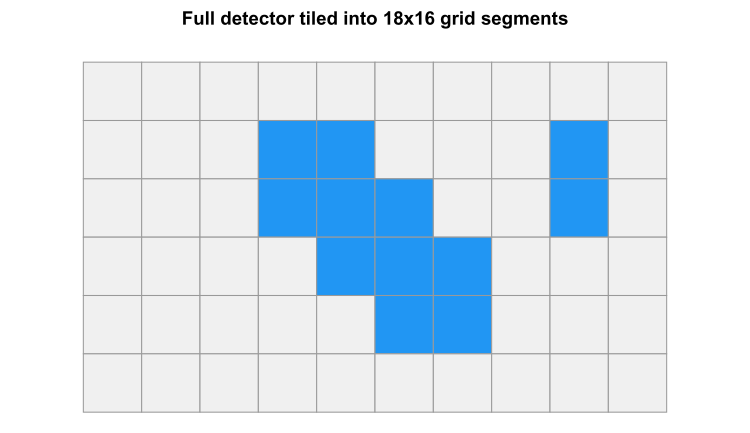

In [4]:
colors = []
for r in range(6):
    row = []
    for c in range(10):
        if (r, c) in ALL_ACTIVE:
            row.append(TRACK)
        else:
            row.append(EMPTY)
    colors.append(row)

d = create_grid_diagram(
    'Full detector tiled into 18x16 grid segments',
    colors, cell_size=28
)
save_and_show(d, 'diagram_01_tiling.png')

---
## Figure 2: Binary Map
After applying the charge threshold, each tile is labeled 1 (above threshold) or 0 (below).

Saved: diagram_02_binary_map.png


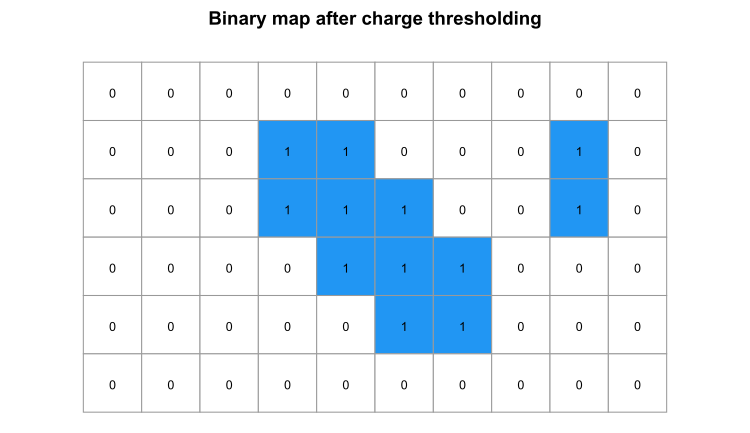

In [5]:
colors = []
labels = []
for r in range(6):
    color_row = []
    label_row = []
    for c in range(10):
        if (r, c) in ALL_ACTIVE:
            color_row.append(TRACK)
            label_row.append('1')
        else:
            color_row.append(WHITE)
            label_row.append('0')
    colors.append(color_row)
    labels.append(label_row)

d = create_grid_diagram(
    'Binary map after charge thresholding',
    colors, labels, cell_size=28
)
save_and_show(d, 'diagram_02_binary_map.png')

---
## Figure 3: King-Move Connectivity
For each active tile, all 8 adjacent neighbors are checked — the same squares a king can reach in chess.

Saved: diagram_03_king_move.png


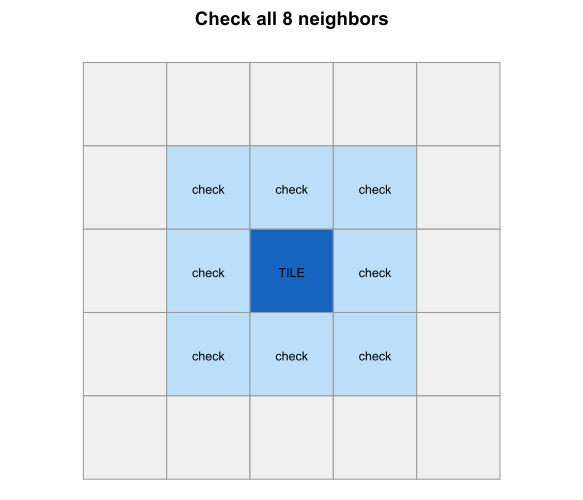

In [7]:
colors = [[EMPTY] * 5 for _ in range(5)]
labels = [[''] * 5 for _ in range(5)]

# Center tile
colors[2][2] = TRACK_DARK
labels[2][2] = 'TILE'

# 8 neighbors
neighbors = [(1,1), (1,2), (1,3), (2,1), (2,3), (3,1), (3,2), (3,3)]
for r, c in neighbors:
    colors[r][c] = NEIGHBOR
    labels[r][c] = 'check'

d = create_grid_diagram(
    'Check all 8 neighbors',
    colors, labels, cell_size=40
)
save_and_show(d, 'diagram_03_king_move.png')

---
## Figure 4: Clustered Result
Connected-component labeling groups adjacent active tiles into distinct clusters.

Saved: diagram_04_clustered.png


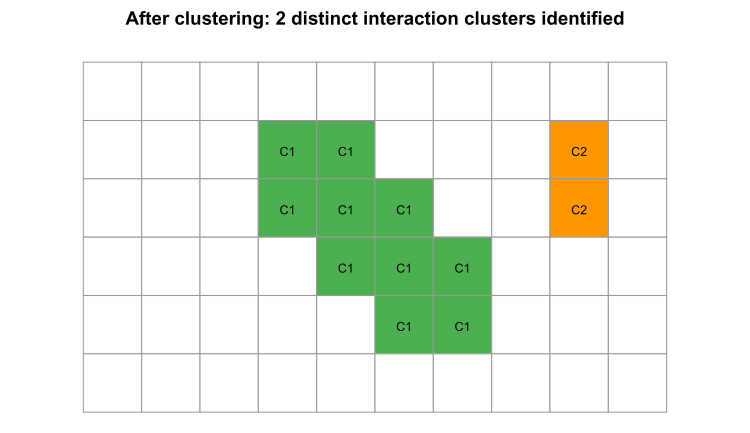

In [8]:
colors = []
labels = []
for r in range(6):
    color_row = []
    label_row = []
    for c in range(10):
        if (r, c) in CLUSTER1_POS:
            color_row.append(CLUSTER1)
            label_row.append('C1')
        elif (r, c) in CLUSTER2_POS:
            color_row.append(CLUSTER2)
            label_row.append('C2')
        else:
            color_row.append(WHITE)
            label_row.append('')
    colors.append(color_row)
    labels.append(label_row)

d = create_grid_diagram(
    'After clustering: 2 distinct interaction clusters identified',
    colors, labels, cell_size=28
)
save_and_show(d, 'diagram_04_clustered.png')

---
## Figure 5: Bounding Box Extraction with Padding
A bounding box (red dashed) is drawn around the cluster plus one tile of padding on each side.

Saved: diagram_05_bbox_extraction.png


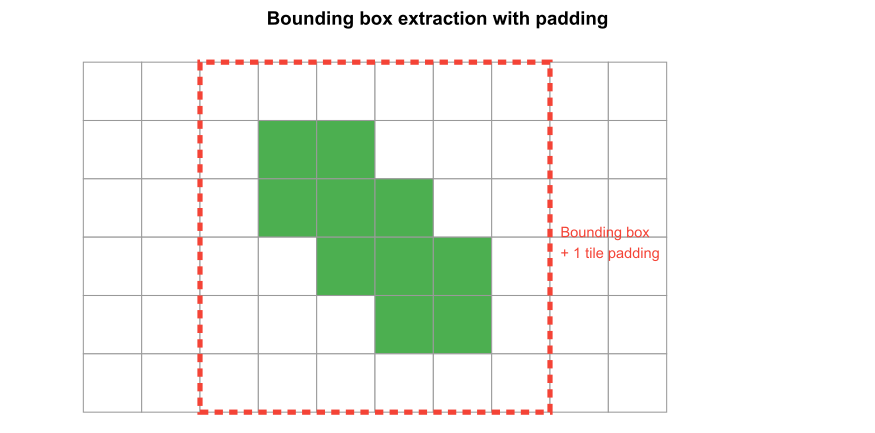

In [9]:
cs = 28
rows, cols = 6, 10
w = cols * cs + 140
h = rows * cs + 40
d = Drawing(w, h)

d.add(String(w / 2, h - 12,
             'Bounding box extraction with padding',
             textAnchor='middle', fontSize=9, fontName='Helvetica-Bold'))

ox, oy = 40, 10

# Draw grid
for r in range(rows):
    for c in range(cols):
        x = ox + c * cs
        y = oy + (rows - 1 - r) * cs
        if (r, c) in CLUSTER1_POS:
            color = CLUSTER1
        else:
            color = WHITE
        d.add(Rect(x, y, cs, cs, fillColor=color,
                   strokeColor=GRID_LINE, strokeWidth=0.5))

# Bounding box with 1 tile padding
# Cluster 1 spans rows 1-4, cols 3-6
pad = 1
min_r, max_r = 1, 4
min_c, max_c = 3, 6

bbox_x = ox + (min_c - pad) * cs
bbox_y = oy + (rows - 1 - (max_r + pad)) * cs
bbox_w = (max_c - min_c + 1 + 2 * pad) * cs
bbox_h = (max_r - min_r + 1 + 2 * pad) * cs

d.add(Rect(bbox_x, bbox_y, bbox_w, bbox_h,
           fillColor=None, strokeColor=BBOX_RED,
           strokeWidth=2.5, strokeDashArray=[4, 3]))

# Labels
d.add(String(bbox_x + bbox_w + 5, bbox_y + bbox_h / 2,
             'Bounding box', fontSize=7, fontName='Helvetica',
             fillColor=BBOX_RED))
d.add(String(bbox_x + bbox_w + 5, bbox_y + bbox_h / 2 - 10,
             '+ 1 tile padding', fontSize=7, fontName='Helvetica',
             fillColor=BBOX_RED))

save_and_show(d, 'diagram_05_bbox_extraction.png')

---
## Figure 6: Padding to Consistent Dimensions
Small interactions are centered and zero-padded. Oversized interactions are cropped.

Saved: diagram_06_padding_strategy.png


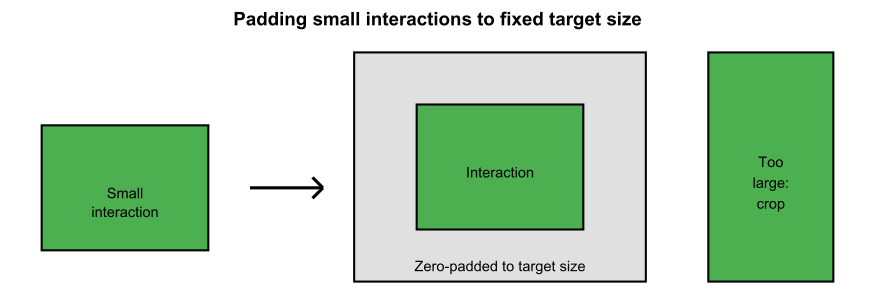

In [10]:
w, h = 420, 140
d = Drawing(w, h)

d.add(String(210, 128,
             'Padding small interactions to fixed target size',
             textAnchor='middle', fontSize=9, fontName='Helvetica-Bold'))

# Small interaction (left)
d.add(Rect(20, 20, 80, 60, fillColor=CLUSTER1,
           strokeColor=BLACK, strokeWidth=1))
d.add(String(60, 45, 'Small', textAnchor='middle',
             fontSize=7, fontName='Helvetica'))
d.add(String(60, 36, 'interaction', textAnchor='middle',
             fontSize=7, fontName='Helvetica'))

# Arrow
d.add(Line(120, 50, 155, 50, strokeColor=BLACK, strokeWidth=1.5))
d.add(Line(150, 45, 155, 50, strokeColor=BLACK, strokeWidth=1.5))
d.add(Line(150, 55, 155, 50, strokeColor=BLACK, strokeWidth=1.5))

# Padded version (center)
d.add(Rect(170, 5, 140, 110, fillColor=PAD_GRAY,
           strokeColor=BLACK, strokeWidth=1))
d.add(Rect(200, 30, 80, 60, fillColor=CLUSTER1,
           strokeColor=BLACK, strokeWidth=1))
d.add(String(240, 55, 'Interaction', textAnchor='middle',
             fontSize=7, fontName='Helvetica'))
d.add(String(240, 10, 'Zero-padded to target size',
             textAnchor='middle', fontSize=7, fontName='Helvetica'))

# Large interaction being cropped (right)
d.add(Rect(340, 5, 60, 110, fillColor=CLUSTER1,
           strokeColor=BLACK, strokeWidth=1))
d.add(String(370, 60, 'Too', textAnchor='middle',
             fontSize=7, fontName='Helvetica'))
d.add(String(370, 50, 'large:', textAnchor='middle',
             fontSize=7, fontName='Helvetica'))
d.add(String(370, 40, 'crop', textAnchor='middle',
             fontSize=7, fontName='Helvetica'))

save_and_show(d, 'diagram_06_padding_strategy.png')

---
## Figure 7: Pipeline Flow Diagram
The complete SCARAB preprocessing pipeline from raw data to training-ready output.

Saved: diagram_07_pipeline_flow.png


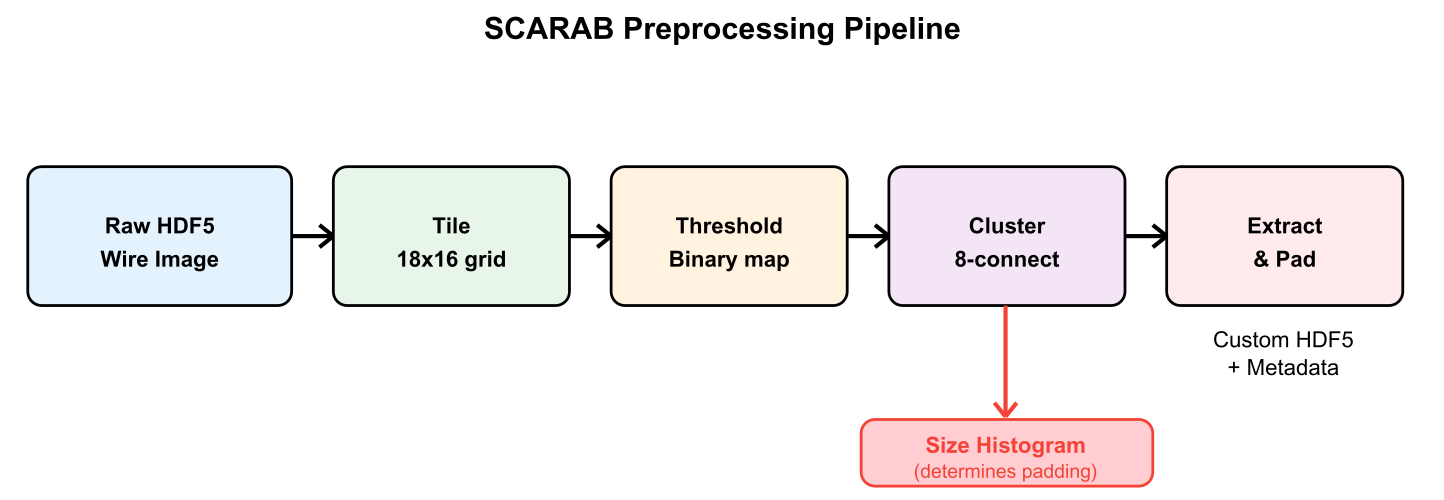

In [11]:
w, h = 520, 180
d = Drawing(w, h)

d.add(String(w / 2, h - 14,
             'SCARAB Preprocessing Pipeline',
             textAnchor='middle', fontSize=11, fontName='Helvetica-Bold'))

# Pipeline boxes
boxes = [
    (10,  70, 95, 50,  'Raw HDF5\nWire Image',   HexColor('#E3F2FD')),
    (120, 70, 85, 50,  'Tile\n18x16 grid',       HexColor('#E8F5E9')),
    (220, 70, 85, 50,  'Threshold\nBinary map',   HexColor('#FFF3E0')),
    (320, 70, 85, 50,  'Cluster\n8-connect',      HexColor('#F3E5F5')),
    (420, 70, 85, 50,  'Extract\n& Pad',          HexColor('#FFEBEE')),
]

for x, y, bw, bh, text, color in boxes:
    d.add(Rect(x, y, bw, bh, fillColor=color,
               strokeColor=BLACK, strokeWidth=1, rx=5, ry=5))
    lines = text.split('\n')
    for i, line in enumerate(lines):
        ly = y + bh/2 - 5 + (len(lines)-1-i)*12 - (len(lines)-1)*6
        d.add(String(x + bw/2, ly, line,
                     textAnchor='middle', fontSize=8,
                     fontName='Helvetica-Bold'))

# Arrows between boxes
for x1, x2 in [(105, 120), (205, 220), (305, 320), (405, 420)]:
    y = 95
    d.add(Line(x1, y, x2, y, strokeColor=BLACK, strokeWidth=1.5))
    d.add(Line(x2-5, y-4, x2, y, strokeColor=BLACK, strokeWidth=1.5))
    d.add(Line(x2-5, y+4, x2, y, strokeColor=BLACK, strokeWidth=1.5))

# Output label
d.add(String(462, 55, 'Custom HDF5', textAnchor='middle',
             fontSize=8, fontName='Helvetica'))
d.add(String(462, 45, '+ Metadata', textAnchor='middle',
             fontSize=8, fontName='Helvetica'))

# Histogram branch from clustering
d.add(Line(362, 70, 362, 30, strokeColor=BBOX_RED, strokeWidth=1.5))
d.add(Line(358, 35, 362, 30, strokeColor=BBOX_RED, strokeWidth=1.5))
d.add(Line(366, 35, 362, 30, strokeColor=BBOX_RED, strokeWidth=1.5))
d.add(Rect(310, 5, 105, 24, fillColor=HexColor('#FFCDD2'),
           strokeColor=BBOX_RED, strokeWidth=1, rx=5, ry=5))
d.add(String(362, 17, 'Size Histogram', textAnchor='middle',
             fontSize=8, fontName='Helvetica-Bold', fillColor=BBOX_RED))
d.add(String(362, 8, '(determines padding)', textAnchor='middle',
             fontSize=7, fontName='Helvetica', fillColor=BBOX_RED))

save_and_show(d, 'diagram_07_pipeline_flow.png', dpi=200)

---
## Summary

All diagrams saved as PNG files in the current directory:

| File | Description |
|------|-------------|
| `diagram_01_tiling.png` | Detector image divided into tile grid |
| `diagram_02_binary_map.png` | Binary map with 0/1 labels after thresholding |
| `diagram_03_king_move.png` | 8-connectivity pattern showing checked neighbors |
| `diagram_04_clustered.png` | Two distinct clusters identified and color-coded |
| `diagram_05_bbox_extraction.png` | Bounding box with padding around a cluster |
| `diagram_06_padding_strategy.png` | Small images padded vs large images cropped |
| `diagram_07_pipeline_flow.png` | Full preprocessing pipeline flow |

### To customize:
- Change colors in the **Color Palette** cell
- Change `CLUSTER1_POS` and `CLUSTER2_POS` to move tracks around
- Change `cell_size` parameter for larger/smaller grid cells
- Add new diagrams by copying any cell and modifying the layout